In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
#loading the data
df = pd.read_csv('worldometer_coronavirus_daily_data.csv')

df.head()

,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN


In [3]:
#checking dataset structure
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

Rows and Columns: (184787, 7)

Column Names:
Index(['date', 'country', 'cumulative_total_cases', 'daily_new_cases',
       'active_cases', 'cumulative_total_deaths', 'daily_new_deaths'],
      dtype='object')


In [4]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  object 
 1   country                  184787 non-null  object 
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          174329 non-null  float64
 4   active_cases             166747 non-null  float64
 5   cumulative_total_deaths  178227 non-null  float64
 6   daily_new_deaths         157850 non-null  float64
dtypes: float64(5), object(2)
memory usage: 9.9+ MB


In [5]:
#missing values
df.isnull().sum()

,0
date,0
country,0
cumulative_total_cases,0
daily_new_cases,10458
active_cases,18040
cumulative_total_deaths,6560
daily_new_deaths,26937


In [6]:
#duplicate records
df.duplicated().sum()

np.int64(0)

#Data Cleaning


In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.fillna(0, inplace=True)

In [11]:
df.isnull().sum()

,0
date,0
country,0
cumulative_total_cases,0
daily_new_cases,0
active_cases,0
cumulative_total_deaths,0
daily_new_deaths,0


# Dataset Summary

1. The dataset contains daily COVID-19 statistics from countries around the world.
2. It includes total cases, new cases, active cases and death counts.
3. The dataset contains 184,787 records and 7 columns.
4. Missing values were found in some columns and cleaned.
5. The dataset can be used to analyze the spread and impact of COVID-19 globally.

## Question 1:
Which countries recorded the highest cumulative COVID-19 cases?

In [12]:
top_cases = df.groupby('country')['cumulative_total_cases'].max()

top_cases = top_cases.sort_values(ascending=False).head(10)

top_cases

,cumulative_total_cases
country,
USA,84209473.0
India,43121599.0
Brazil,30682094.0
France,29160802.0
Germany,25774509.0
UK,22159805.0
Russia,18255337.0
South Korea,17756627.0
Italy,17030711.0


The USA recorded the highest cumulative COVID-19 cases, followed by India and Brazil. This indicates a significant spread of the virus in these countries.


## Question 2:
Which countries recorded the highest cumulative deaths?

In [13]:
top_deaths = df.groupby('country')['cumulative_total_deaths'].max()

top_deaths = top_deaths.sort_values(ascending=False).head(10)

top_deaths

,cumulative_total_deaths
country,
USA,1026646.0
Brazil,664920.0
India,524214.0
Russia,377571.0
Mexico,324465.0
Peru,213023.0
UK,176708.0
Italy,165182.0
Indonesia,156453.0


The USA recorded the highest cumulative deaths. Brazil and India also experienced substantial mortality during the pandemic.

## Question 3:
Which countries recorded the highest active COVID-19 cases?

In [14]:
top_active = df.groupby('country')['active_cases'].max()

top_active = top_active.sort_values(ascending=False).head(10)

top_active

,active_cases
country,
USA,17935434.0
France,6852832.0
Germany,4575633.0
UK,4459061.0
Spain,3846305.0
India,3741179.0
Brazil,3219406.0
Viet Nam,3169398.0
Italy,2759074.0


Countries with large populations generally showed higher active case counts, indicating ongoing transmission during peak periods.

## Question 4:
How did global cumulative COVID-19 cases change over time?

In [15]:
global_cases = df.groupby('date')['cumulative_total_cases'].sum()

global_cases.head()

,cumulative_total_cases
date,
2020-01-22,571.0
2020-01-23,830.0
2020-01-24,1287.0
2020-01-25,1975.0
2020-01-26,2744.0


Global cumulative cases increased steadily over time, reflecting the worldwide spread of COVID-19 throughout the pandemic.

## Question 5:
Which countries reported the highest daily new COVID-19 cases?

In [16]:
top_daily_cases = df.groupby('country')['daily_new_cases'].max()

top_daily_cases = top_daily_cases.sort_values(ascending=False).head(10)

top_daily_cases

,daily_new_cases
country,
USA,909610.0
South Korea,621328.0
France,501635.0
India,414433.0
Germany,305592.0
Brazil,286050.0
UK,275601.0
Italy,228740.0
Viet Nam,214691.0


Several countries experienced sudden spikes in daily new cases, suggesting multiple waves of infection during the pandemic.

# Data Visualizations


## Visualization 1: Top 10 Countries by Total COVID-19 Cases

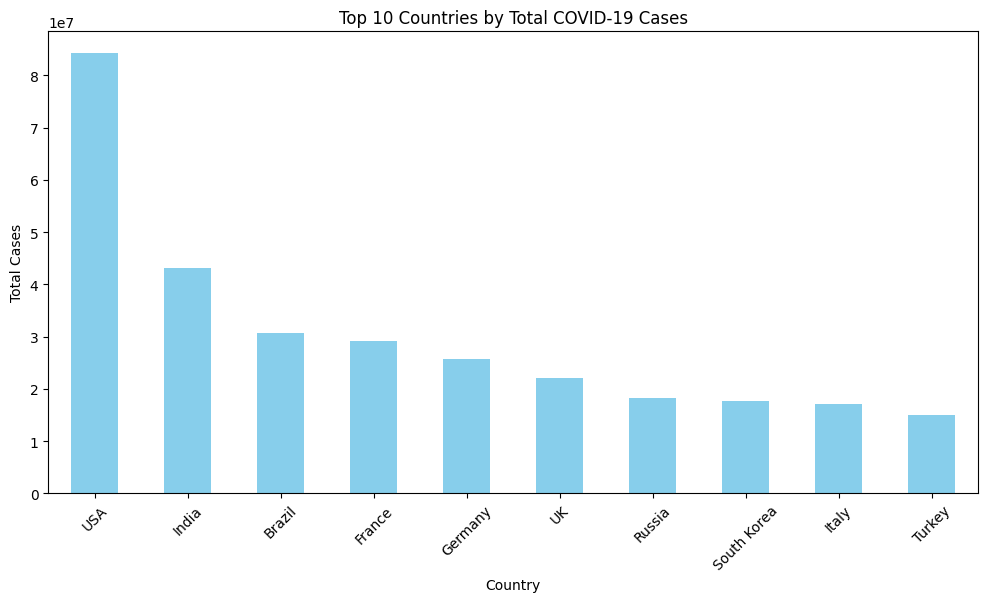

In [17]:
plt.figure(figsize=(12,6))

top_cases.plot(
    kind='bar',
    color='skyblue'
)

plt.title('Top 10 Countries by Total COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)

plt.show()

### Observation

The USA, India, and Brazil recorded the highest cumulative COVID-19 cases among all countries in the dataset.

## Visualization 2: Global COVID-19 Cases Over Time

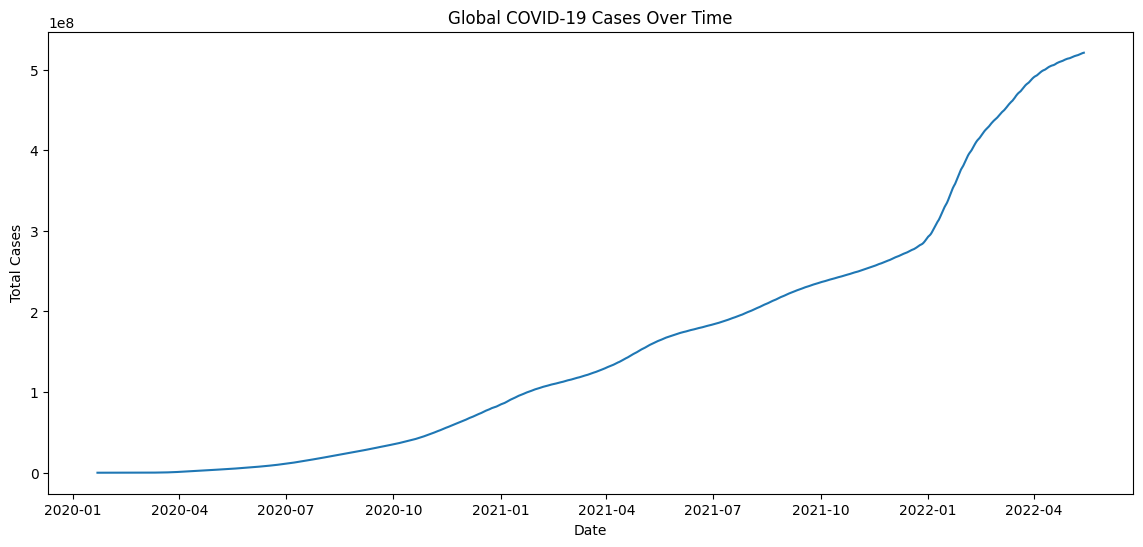

In [18]:
global_cases = df.groupby('date')['cumulative_total_cases'].sum()

plt.figure(figsize=(14,6))

plt.plot(global_cases)

plt.title('Global COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Cases')

plt.show()

### Observation

The graph shows a continuous increase in global COVID-19 cases, indicating the rapid worldwide spread of the pandemic.

## Visualization 3: Distribution of Daily New Cases

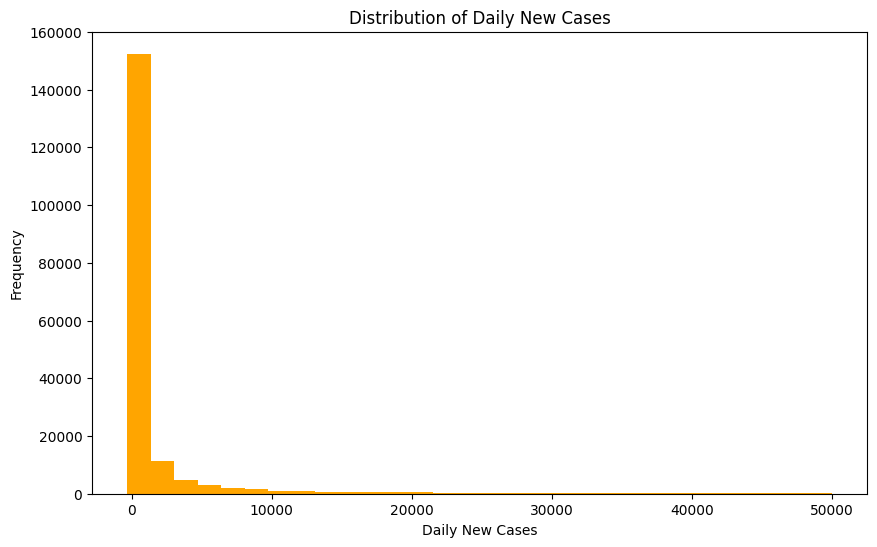

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df['daily_new_cases'] < 50000]['daily_new_cases'],
    bins=30,
    color='orange'
)

plt.title('Distribution of Daily New Cases')
plt.xlabel('Daily New Cases')
plt.ylabel('Frequency')

plt.show()

### Observation

Most daily case counts are concentrated in lower ranges, while a few extreme spikes represent major outbreak periods.

## Visualization 4: Total Cases vs Total Deaths

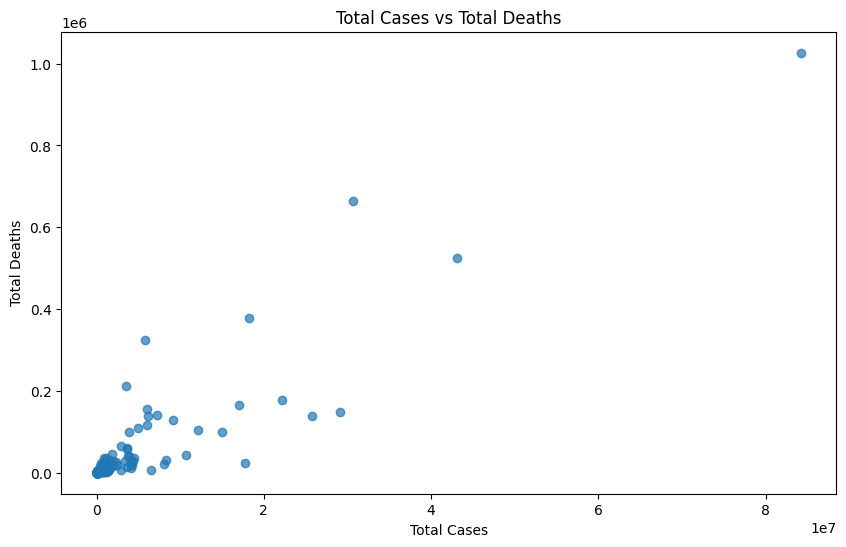

In [20]:
country_data = df.groupby('country').agg({
    'cumulative_total_cases':'max',
    'cumulative_total_deaths':'max'
})

plt.figure(figsize=(10,6))

plt.scatter(
    country_data['cumulative_total_cases'],
    country_data['cumulative_total_deaths'],
    alpha=0.7
)

plt.title('Total Cases vs Total Deaths')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')

plt.show()

### Observation

Countries with higher case counts generally experienced higher death counts, indicating a positive relationship between infections and fatalities.

## Visualization 5: Share of Cases Among Top 5 Countries

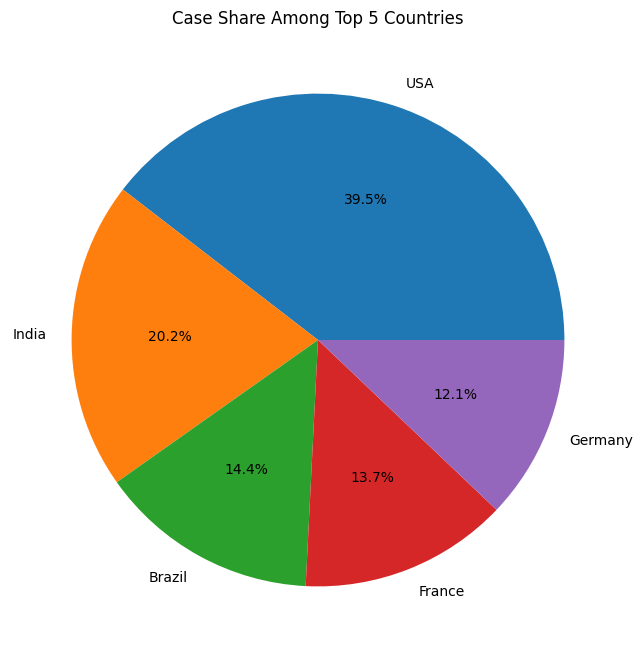

In [21]:
top5 = top_cases.head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)

plt.title('Case Share Among Top 5 Countries')

plt.show()

### Observation

A small group of countries accounts for a significant proportion of total global COVID-19 cases.

## Visualization 6: Correlation Heatmap

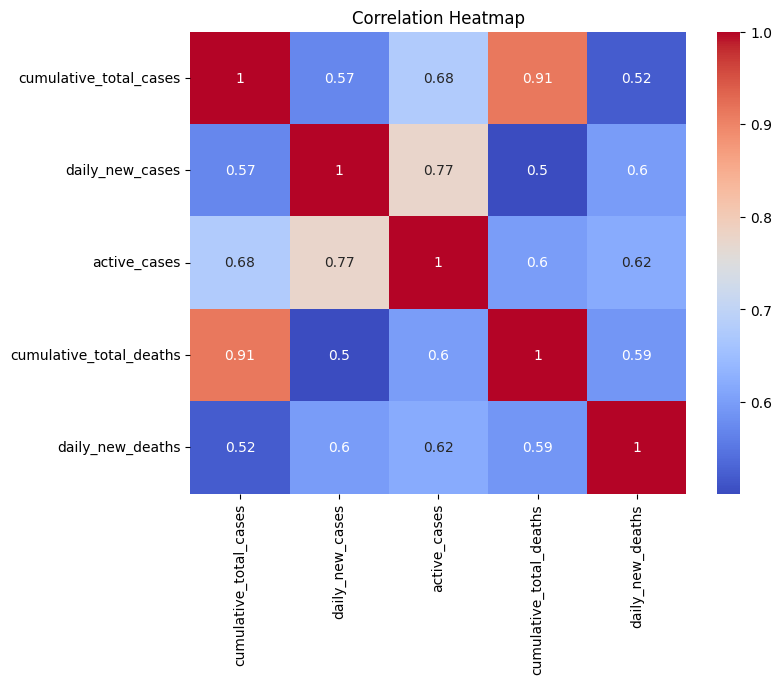

In [22]:
numeric_cols = [
    'cumulative_total_cases',
    'daily_new_cases',
    'active_cases',
    'cumulative_total_deaths',
    'daily_new_deaths'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

The heatmap shows strong positive correlations between total cases, active cases, and total deaths.

# Insights Report

## Insight 1

The USA recorded the highest cumulative COVID-19 cases and deaths among all countries in the dataset, highlighting the significant impact of the pandemic on the country.

## Insight 2

A small number of countries, including the USA, India, Brazil, France, and Germany, accounted for a large proportion of global COVID-19 cases.

## Insight 3

The line chart shows that global cumulative COVID-19 cases increased continuously over time, demonstrating the rapid worldwide spread of the virus.

## Insight 4

Countries with higher cumulative case counts generally experienced higher death counts, indicating a strong relationship between infections and fatalities.

## Insight 5

The correlation heatmap reveals strong positive correlations between cumulative cases, active cases, and deaths, suggesting that increases in infections are often associated with increases in severe outcomes.

# Most Surprising Finding

The most surprising finding was that a relatively small group of countries contributed a very large share of the world's total COVID-19 cases and deaths, demonstrating how unevenly the pandemic affected different regions.

# Conclusion

This project performed an exploratory data analysis of a global COVID-19 dataset using Python, Pandas, Matplotlib, and Seaborn.

The data was cleaned and analyzed to identify trends, patterns, and relationships among COVID-19 cases and deaths across countries.

Several visualizations were created to better understand the spread and impact of the pandemic.

The analysis showed significant differences between countries in terms of cases, active infections, and mortality.

Overall, this project demonstrates how data analysis techniques can be used to extract meaningful insights from real-world healthcare datasets.

# Cleaning Decisions

1. Converted the date column into datetime format.
2. Checked for duplicate records and removed them if present.
3. Replaced missing values with 0 to handle unavailable COVID-19 statistics.
4. Verified that no null values remained after cleaning.
5. Prepared the dataset for analysis and visualization.

# Table of Contents

1. Project Introduction
2. Dataset Summary
3. Data Cleaning
4. Exploratory Data Analysis
5. Data Visualizations
6. Insights Report
7. Most Surprising Finding
8. Conclusion